In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
from scion import Spectral
spectral = Spectral()

In [2]:
PATH = "/data/imagenet-runs/logs/90ep-Scion-3x-wd-corrected-unbiased-1.0-init-mo/checkpoints/model_step_28151.pth.tar"

In [3]:
state_dict = torch.load(PATH, weights_only=True)

In [4]:
state_dict.keys()

dict_keys(['step', 'state_dict', 'best_acc1', 'optimizer'])

In [5]:
state_dict['state_dict'].keys()

odict_keys(['pos_embedding', 'conv_proj.weight', 'encoder.layers.encoder_layer_0.self_attention.qkv_w', 'encoder.layers.encoder_layer_0.self_attention.out.weight', 'encoder.layers.encoder_layer_0.mlp.0.weight', 'encoder.layers.encoder_layer_0.mlp.3.weight', 'encoder.layers.encoder_layer_1.self_attention.qkv_w', 'encoder.layers.encoder_layer_1.self_attention.out.weight', 'encoder.layers.encoder_layer_1.mlp.0.weight', 'encoder.layers.encoder_layer_1.mlp.3.weight', 'encoder.layers.encoder_layer_2.self_attention.qkv_w', 'encoder.layers.encoder_layer_2.self_attention.out.weight', 'encoder.layers.encoder_layer_2.mlp.0.weight', 'encoder.layers.encoder_layer_2.mlp.3.weight', 'encoder.layers.encoder_layer_3.self_attention.qkv_w', 'encoder.layers.encoder_layer_3.self_attention.out.weight', 'encoder.layers.encoder_layer_3.mlp.0.weight', 'encoder.layers.encoder_layer_3.mlp.3.weight', 'encoder.layers.encoder_layer_4.self_attention.qkv_w', 'encoder.layers.encoder_layer_4.self_attention.out.weight', 

In [7]:
for k, v in state_dict['state_dict'].items():
    if k.startswith('encoder.'):
        print(k, v.shape)

encoder.layers.encoder_layer_0.self_attention.qkv_w torch.Size([3, 384, 384])
encoder.layers.encoder_layer_0.self_attention.out.weight torch.Size([384, 384])
encoder.layers.encoder_layer_0.mlp.0.weight torch.Size([1536, 384])
encoder.layers.encoder_layer_0.mlp.3.weight torch.Size([384, 1536])
encoder.layers.encoder_layer_1.self_attention.qkv_w torch.Size([3, 384, 384])
encoder.layers.encoder_layer_1.self_attention.out.weight torch.Size([384, 384])
encoder.layers.encoder_layer_1.mlp.0.weight torch.Size([1536, 384])
encoder.layers.encoder_layer_1.mlp.3.weight torch.Size([384, 1536])
encoder.layers.encoder_layer_2.self_attention.qkv_w torch.Size([3, 384, 384])
encoder.layers.encoder_layer_2.self_attention.out.weight torch.Size([384, 384])
encoder.layers.encoder_layer_2.mlp.0.weight torch.Size([1536, 384])
encoder.layers.encoder_layer_2.mlp.3.weight torch.Size([384, 1536])
encoder.layers.encoder_layer_3.self_attention.qkv_w torch.Size([3, 384, 384])
encoder.layers.encoder_layer_3.self_atte

In [13]:
for k, v in state_dict['state_dict'].items():
    if k.startswith('encoder.'):
        print(k, torch.linalg.matrix_norm(v) / spectral.scale(*v.shape[-2:]))

encoder.layers.encoder_layer_0.self_attention.qkv_w tensor([11.6682, 12.4883,  7.5493], device='cuda:0')
encoder.layers.encoder_layer_0.self_attention.out.weight tensor(5.3500, device='cuda:0')
encoder.layers.encoder_layer_0.mlp.0.weight tensor(21.6919, device='cuda:0')
encoder.layers.encoder_layer_0.mlp.3.weight tensor(13.6216, device='cuda:0')
encoder.layers.encoder_layer_1.self_attention.qkv_w tensor([18.0109, 17.1683,  9.9878], device='cuda:0')
encoder.layers.encoder_layer_1.self_attention.out.weight tensor(9.9560, device='cuda:0')
encoder.layers.encoder_layer_1.mlp.0.weight tensor(17.5966, device='cuda:0')
encoder.layers.encoder_layer_1.mlp.3.weight tensor(18.0650, device='cuda:0')
encoder.layers.encoder_layer_2.self_attention.qkv_w tensor([15.4559, 15.2102, 12.4053], device='cuda:0')
encoder.layers.encoder_layer_2.self_attention.out.weight tensor(12.1804, device='cuda:0')
encoder.layers.encoder_layer_2.mlp.0.weight tensor(17.6785, device='cuda:0')
encoder.layers.encoder_layer_2.m

In [14]:
for k, v in state_dict['state_dict'].items():
    if k.startswith('encoder.'):
        print(k, torch.linalg.matrix_norm(v, ord=2) / spectral.scale(*v.shape[-2:]))

encoder.layers.encoder_layer_0.self_attention.qkv_w tensor([1.8729, 2.2270, 1.7300], device='cuda:0')
encoder.layers.encoder_layer_0.self_attention.out.weight tensor(1.5420, device='cuda:0')
encoder.layers.encoder_layer_0.mlp.0.weight tensor(2.0529, device='cuda:0')
encoder.layers.encoder_layer_0.mlp.3.weight tensor(1.5280, device='cuda:0')
encoder.layers.encoder_layer_1.self_attention.qkv_w tensor([3.8016, 3.4608, 1.1765], device='cuda:0')
encoder.layers.encoder_layer_1.self_attention.out.weight tensor(1.1280, device='cuda:0')
encoder.layers.encoder_layer_1.mlp.0.weight tensor(1.6207, device='cuda:0')
encoder.layers.encoder_layer_1.mlp.3.weight tensor(1.8133, device='cuda:0')
encoder.layers.encoder_layer_2.self_attention.qkv_w tensor([1.8727, 1.8694, 1.6898], device='cuda:0')
encoder.layers.encoder_layer_2.self_attention.out.weight tensor(1.4873, device='cuda:0')
encoder.layers.encoder_layer_2.mlp.0.weight tensor(1.6833, device='cuda:0')
encoder.layers.encoder_layer_2.mlp.3.weight ten

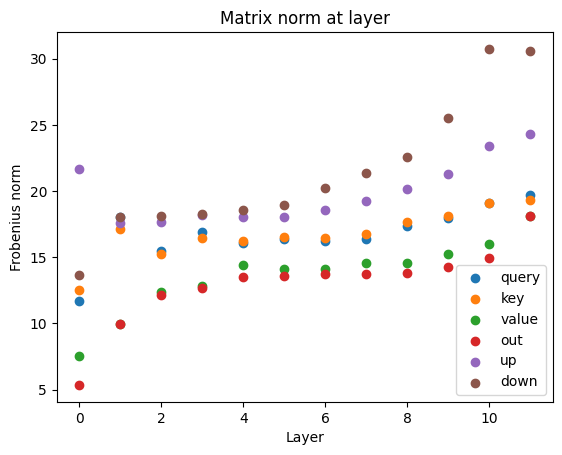

In [28]:
def plot_norm(sd, ord='fro', t='plot', name='Frobenius'):
    spectral = Spectral()
    query, key, value = [], [], []
    out = []
    up = []
    down = []
    layers = range(12)
    for i in layers:
        prefix = f'encoder.layers.encoder_layer_{i}.' 
        w = sd[prefix + 'self_attention.qkv_w']
        q, k, v = torch.linalg.matrix_norm(w, ord=ord) / spectral.scale(*w.shape[-2:])
        query.append(q.item())
        key.append(k.item())
        value.append(v.item())
        w = sd[prefix + 'self_attention.out.weight']
        o = torch.linalg.matrix_norm(w, ord=ord) / spectral.scale(*w.shape[-2:])
        out.append(o.item())
        w = sd[prefix + 'mlp.0.weight']
        u = torch.linalg.matrix_norm(w, ord=ord) / spectral.scale(*w.shape[-2:])
        up.append(u.item())
        w = sd[prefix + 'mlp.3.weight']
        d = torch.linalg.matrix_norm(w, ord=ord) / spectral.scale(*w.shape[-2:])
        down.append(d.item())
    getattr(plt, t)(layers, query, label='query')
    getattr(plt, t)(layers, key, label='key')
    getattr(plt, t)(layers, value, label='value')
    getattr(plt, t)(layers, out, label='out')
    getattr(plt, t)(layers, up, label='up')
    getattr(plt, t)(layers, down, label='down')
    plt.title('Matrix norm at layer')
    plt.xlabel('Layer')
    plt.ylabel(name + ' norm')
    plt.legend()

name = 'Frobenius'
t = 'scatter'
plot_norm(state_dict['state_dict'], t=t, name=name)
plt.savefig(f'matrix_{name.lower()}_{t}.png')

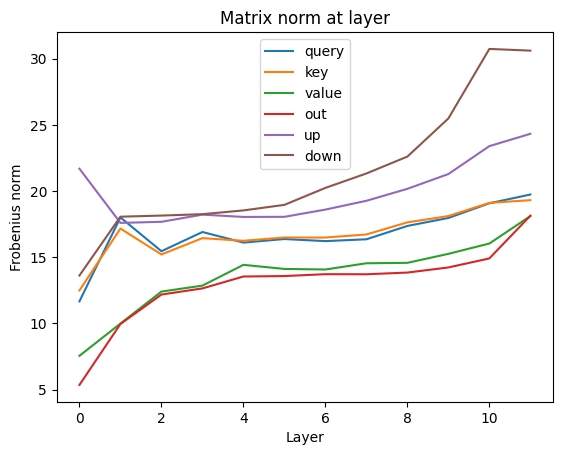

In [29]:
name = 'Frobenius'
t = 'plot'
plot_norm(state_dict['state_dict'], t=t, name=name)
plt.savefig(f'matrix_{name.lower()}_{t}.png')

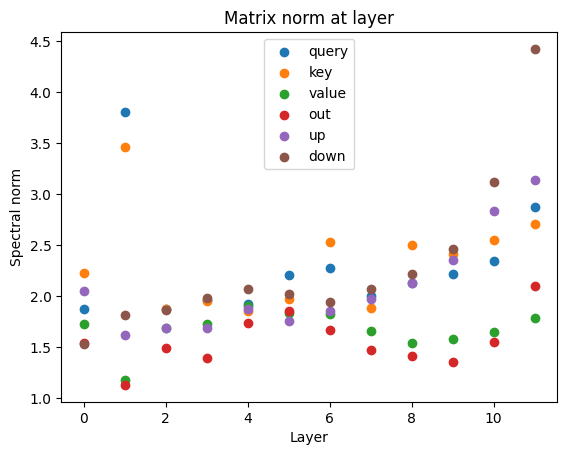

In [26]:
name = 'spectral'
t = 'scatter'
plot_norm(state_dict['state_dict'], ord=2, t=t, name=name.capitalize())
plt.savefig(f'matrix_{name}_{t}.png')

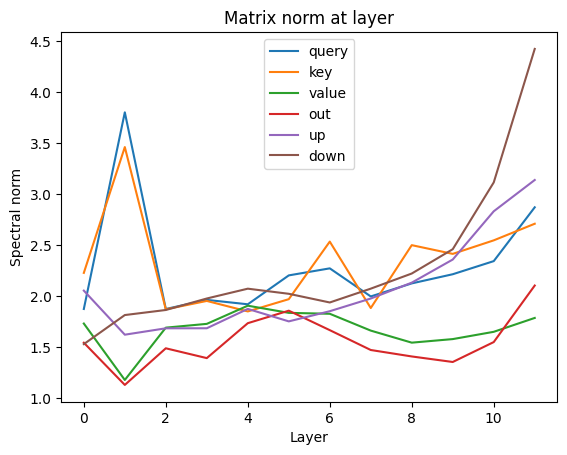

In [27]:
name = 'spectral'
t = 'plot'
plot_norm(state_dict['state_dict'], ord=2, t=t, name=name.capitalize())
plt.savefig(f'matrix_{name}_{t}.png')

In [3]:
PATH = "/media/jason-chou/T31/modded-nanogpt/logs/09dad103-f142-4e15-9a27-8c0a3fb3c51a/state_step381723.pt" # ScionC
state_dict = torch.load(PATH, weights_only=True)

In [4]:
state_dict.keys()

dict_keys(['step', 'code', 'model', 'optimizers'])

In [7]:
for k, v in state_dict['model'].items(): print(k, v.shape)

_orig_mod.transformer.wte.weight torch.Size([50304, 768])
_orig_mod.transformer.h.0.attn.c_qkv torch.Size([3, 768, 768])
_orig_mod.transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
_orig_mod.transformer.h.0.mlp.c_fc.weight torch.Size([3072, 768])
_orig_mod.transformer.h.0.mlp.c_proj.weight torch.Size([768, 3072])
_orig_mod.transformer.h.1.attn.c_qkv torch.Size([3, 768, 768])
_orig_mod.transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
_orig_mod.transformer.h.1.mlp.c_fc.weight torch.Size([3072, 768])
_orig_mod.transformer.h.1.mlp.c_proj.weight torch.Size([768, 3072])
_orig_mod.transformer.h.2.attn.c_qkv torch.Size([3, 768, 768])
_orig_mod.transformer.h.2.attn.c_proj.weight torch.Size([768, 768])
_orig_mod.transformer.h.2.mlp.c_fc.weight torch.Size([3072, 768])
_orig_mod.transformer.h.2.mlp.c_proj.weight torch.Size([768, 3072])
_orig_mod.transformer.h.3.attn.c_qkv torch.Size([3, 768, 768])
_orig_mod.transformer.h.3.attn.c_proj.weight torch.Size([768, 768])
_orig_mod.transf

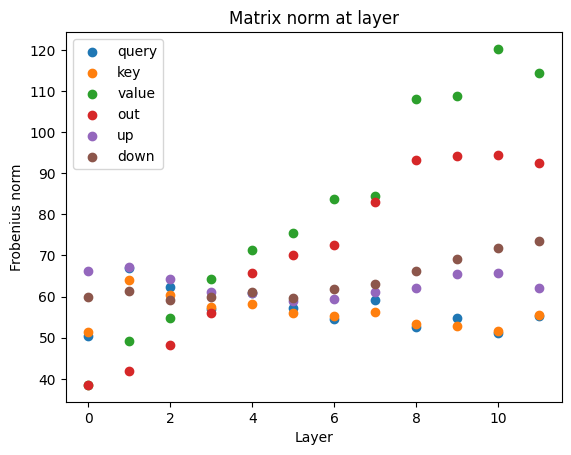

In [9]:
def plot_norm(sd, ord='fro', t='plot', name='Frobenius'):
    spectral = Spectral()
    query, key, value = [], [], []
    out = []
    up = []
    down = []
    layers = range(12)
    for i in layers:
        prefix = f'_orig_mod.transformer.h.{i}.' 
        w = sd[prefix + 'attn.c_qkv']
        q, k, v = torch.linalg.matrix_norm(w, ord=ord) / spectral.scale(*w.shape[-2:])
        query.append(q.item())
        key.append(k.item())
        value.append(v.item())
        w = sd[prefix + 'attn.c_proj.weight']
        o = torch.linalg.matrix_norm(w, ord=ord) / spectral.scale(*w.shape[-2:])
        out.append(o.item())
        w = sd[prefix + 'mlp.c_fc.weight']
        u = torch.linalg.matrix_norm(w, ord=ord) / spectral.scale(*w.shape[-2:])
        up.append(u.item())
        w = sd[prefix + 'mlp.c_proj.weight']
        d = torch.linalg.matrix_norm(w, ord=ord) / spectral.scale(*w.shape[-2:])
        down.append(d.item())
    getattr(plt, t)(layers, query, label='query')
    getattr(plt, t)(layers, key, label='key')
    getattr(plt, t)(layers, value, label='value')
    getattr(plt, t)(layers, out, label='out')
    getattr(plt, t)(layers, up, label='up')
    getattr(plt, t)(layers, down, label='down')
    plt.title('Matrix norm at layer')
    plt.xlabel('Layer')
    plt.ylabel(name + ' norm')
    plt.legend()

name = 'Frobenius'
t = 'scatter'
plot_norm(state_dict['model'], t=t, name=name)
plt.savefig(f'modded_nanogpt_matrix_{name.lower()}_{t}.png')

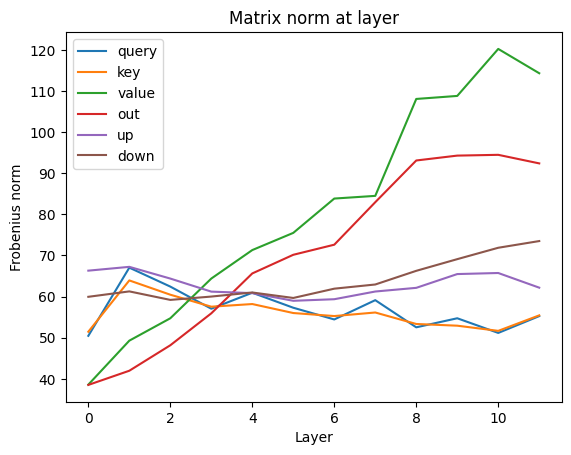

In [10]:
t = 'plot'
plot_norm(state_dict['model'], t=t, name=name)
plt.savefig(f'modded_nanogpt_matrix_{name.lower()}_{t}.png')

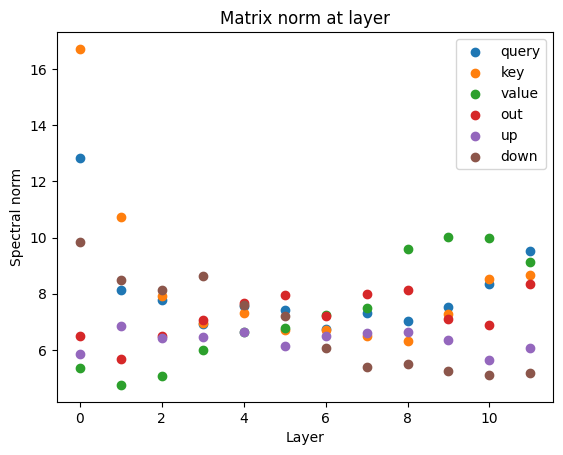

In [11]:
name = 'spectral'
t = 'scatter'
plot_norm(state_dict['model'], ord=2, t=t, name=name.capitalize())
plt.savefig(f'modded_nanogpt_matrix_{name}_{t}.png')

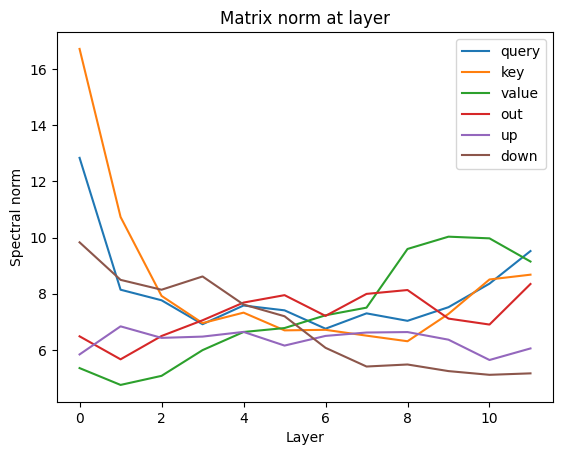

In [12]:
t = 'plot'
plot_norm(state_dict['model'], ord=2, t=t, name=name.capitalize())
plt.savefig(f'modded_nanogpt_matrix_{name}_{t}.png')